# Análise exploratória da série de ouro

**Etapa:** compreensão da série antes da modelagem

A exploração mostra nível, retornos, externas, distribuições, correlações, ACF, PACF e estacionariedade. As decisões usam somente o treino.

**Entrada:** base modelável, série bruta e protocolo  
**Resultado principal:** evidências visuais e estatísticas para interpretar a série


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Exploração no trecho de treino

### Visão rápida dos dados

Antes dos gráficos, conferimos tamanho, período e as primeiras observações da base modelável.

In [ ]:
# Visão rápida da base modelável
eda_data = load_data()
eda_overview = pd.DataFrame(
    {
        "indicador": ["linhas modeláveis", "colunas", "início", "fim", "valores ausentes", "datas duplicadas"],
        "valor": [
            len(eda_data),
            eda_data.shape[1],
            eda_data["DATE"].min().date(),
            eda_data["DATE"].max().date(),
            int(eda_data.isna().sum().sum()),
            int(eda_data["DATE"].duplicated().sum()),
        ],
    }
)
display(eda_overview)
display(eda_data[["DATE", "GOLD_PRICE", "TREASURY_10Y", "FED_FUNDS_RATE", "TARGET"]].head())

indicador,valor
linhas modeláveis,9864
colunas,16
início,1968-04-29
fim,2014-04-09
valores ausentes,0
datas duplicadas,0


DATE,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,TARGET
1968-04-29,38.55,5.71,6.13,39.10
1968-04-30,39.10,5.73,6.13,39.10
1968-05-01,39.10,5.74,6.25,39.25
1968-05-02,39.25,5.73,6.38,39.60
1968-05-03,39.60,5.76,6.25,39.70


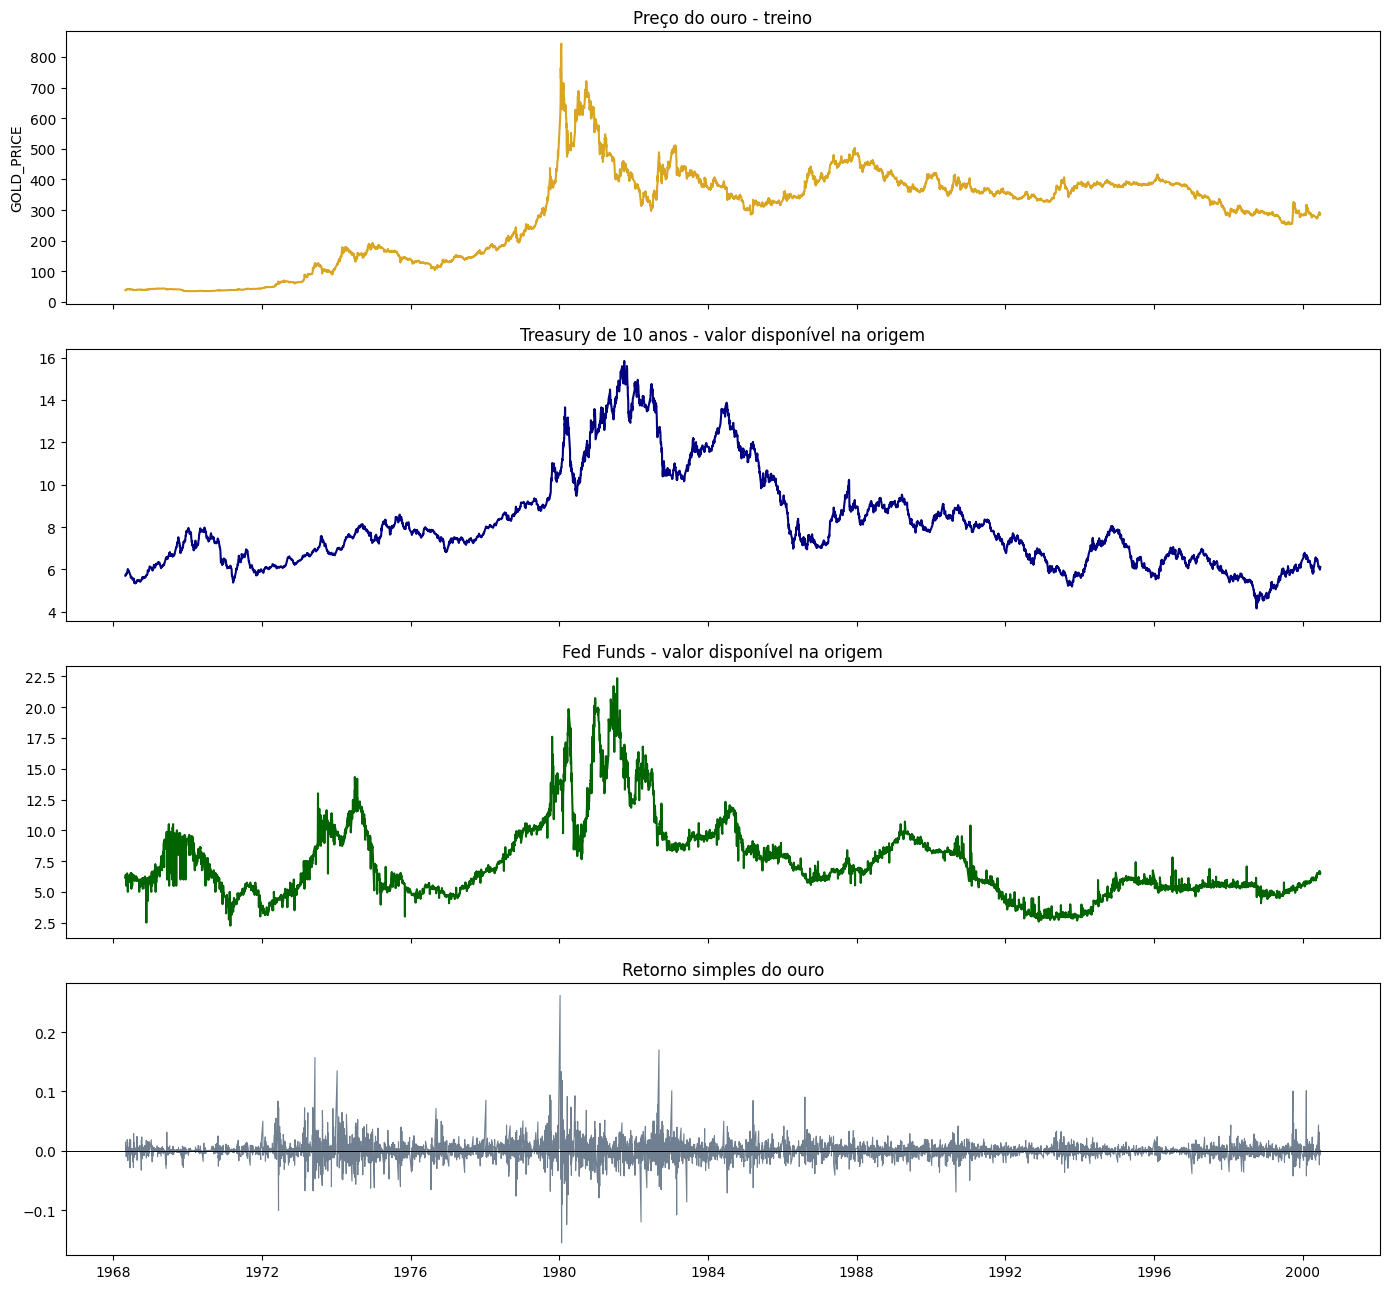

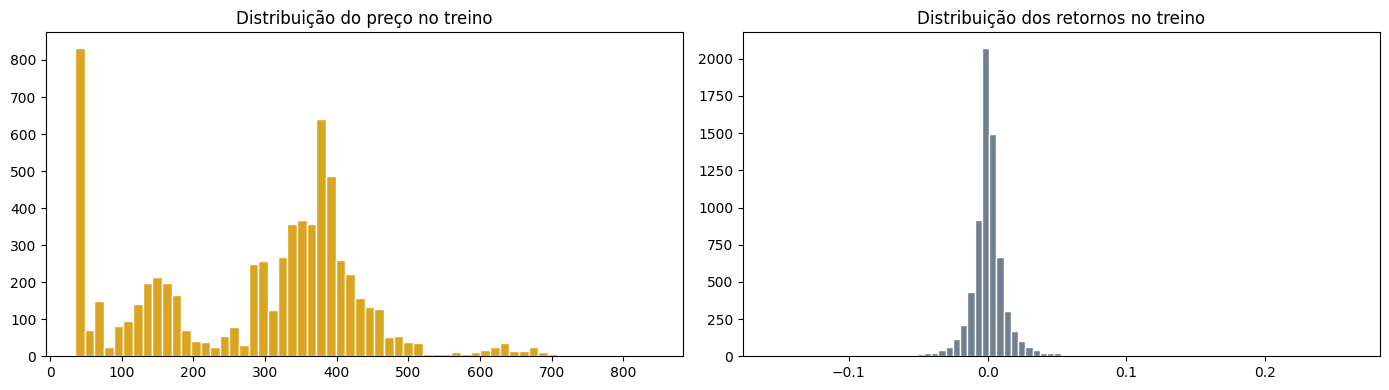

,count,mean,std,min,25%,50%,75%,max
GOLD_PRICE,6904.0,285.4734,149.4355,34.7750,148.8875,333.85,385.8625,843.0000
RETURN,6903.0,0.0004,0.0147,-0.1554,-0.0048,0.00,0.0050,0.2618
TREASURY_10Y,6904.0,8.0931,2.2395,4.1600,6.4700,7.53,8.9200,15.8400
FED_FUNDS_RATE,6904.0,7.3427,3.1111,2.2500,5.2700,6.46,8.9500,22.3600


In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

df = load_data()
protocol = load_protocol()
train_end = protocol["splits"]["train_end"]
train = df.iloc[:train_end].copy()
train["RETURN"] = train["GOLD_PRICE"].pct_change()

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)
axes[0].plot(train["DATE"], train["GOLD_PRICE"], color="goldenrod")
axes[0].set_title("Preço do ouro - treino")
axes[0].set_ylabel("GOLD_PRICE")
axes[1].plot(train["DATE"], train["TREASURY_10Y"], color="navy")
axes[1].set_title("Treasury de 10 anos - valor disponível na origem")
axes[2].plot(train["DATE"], train["FED_FUNDS_RATE"], color="darkgreen")
axes[2].set_title("Fed Funds - valor disponível na origem")
axes[3].plot(train["DATE"], train["RETURN"], color="slategray", linewidth=0.8)
axes[3].axhline(0, color="black", linewidth=0.7)
axes[3].set_title("Retorno simples do ouro")
plt.tight_layout()
plt.savefig(OUT / "02_series_treino.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train["GOLD_PRICE"], bins=60, color="goldenrod", edgecolor="white")
axes[0].set_title("Distribuição do preço no treino")
axes[1].hist(train["RETURN"].dropna(), bins=80, color="slategray", edgecolor="white")
axes[1].set_title("Distribuição dos retornos no treino")
plt.tight_layout()
plt.savefig(OUT / "03_distribuicoes_treino.png", dpi=150, bbox_inches="tight")
plt.show()

summary_columns = ["GOLD_PRICE", "RETURN", "TREASURY_10Y", "FED_FUNDS_RATE"]
descriptive = train[summary_columns].describe().T
display(descriptive.round(4))
descriptive.to_csv(OUT / "eda_descriptive_statistics.csv")

correlation_columns = [
    "TARGET",
    *protocol["candidate_features"],
]


,TARGET,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5
TARGET,1.000,0.999,0.474,0.306,0.001,-0.002,-0.005,0.042,0.999,0.997,0.989,0.998,0.485
GOLD_PRICE,0.999,1.000,0.475,0.307,0.001,-0.001,-0.005,0.042,0.999,0.997,0.990,0.999,0.486
TREASURY_10Y,0.474,0.475,1.000,0.797,0.004,-0.000,-0.016,-0.014,0.475,0.478,0.484,0.477,0.433
FED_FUNDS_RATE,0.306,0.307,0.797,1.000,-0.004,0.007,-0.036,-0.016,0.307,0.311,0.319,0.309,0.449
DOW_SIN,0.001,0.001,0.004,-0.004,1.000,0.219,0.016,-0.037,0.000,0.001,0.001,0.001,0.007
DOW_COS,-0.002,-0.001,-0.000,0.007,0.219,1.000,0.014,0.011,-0.001,-0.001,0.000,-0.001,-0.009
MONTH_SIN,-0.005,-0.005,-0.016,-0.036,0.016,0.014,1.000,0.012,-0.004,-0.002,0.006,-0.003,0.024
MONTH_COS,0.042,0.042,-0.014,-0.016,-0.037,0.011,0.012,1.000,0.041,0.042,0.041,0.042,0.058
GOLD_LAG_1,0.999,0.999,0.475,0.307,0.000,-0.001,-0.004,0.041,1.000,0.998,0.990,0.999,0.485
GOLD_LAG_5,0.997,0.997,0.478,0.311,0.001,-0.001,-0.002,0.042,0.998,1.000,0.993,0.999,0.484


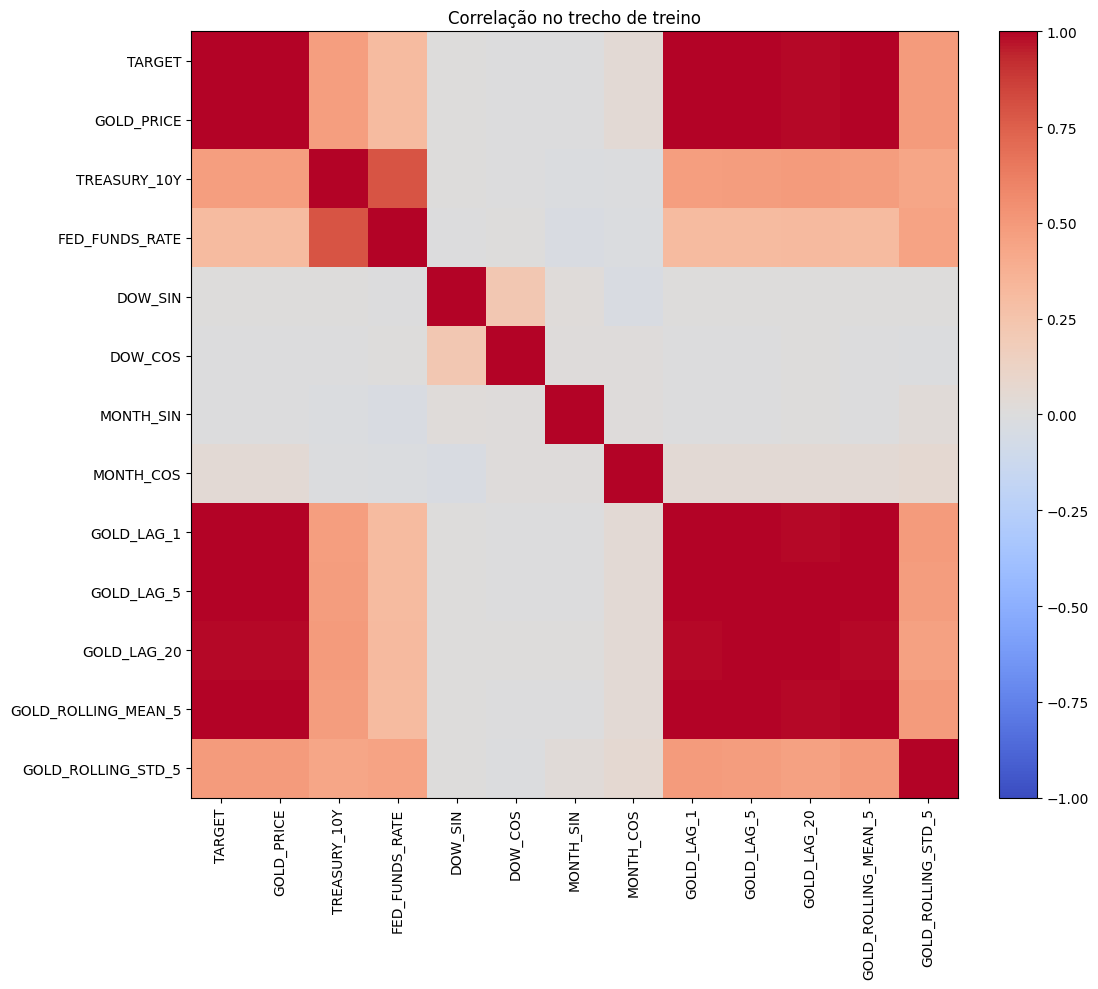

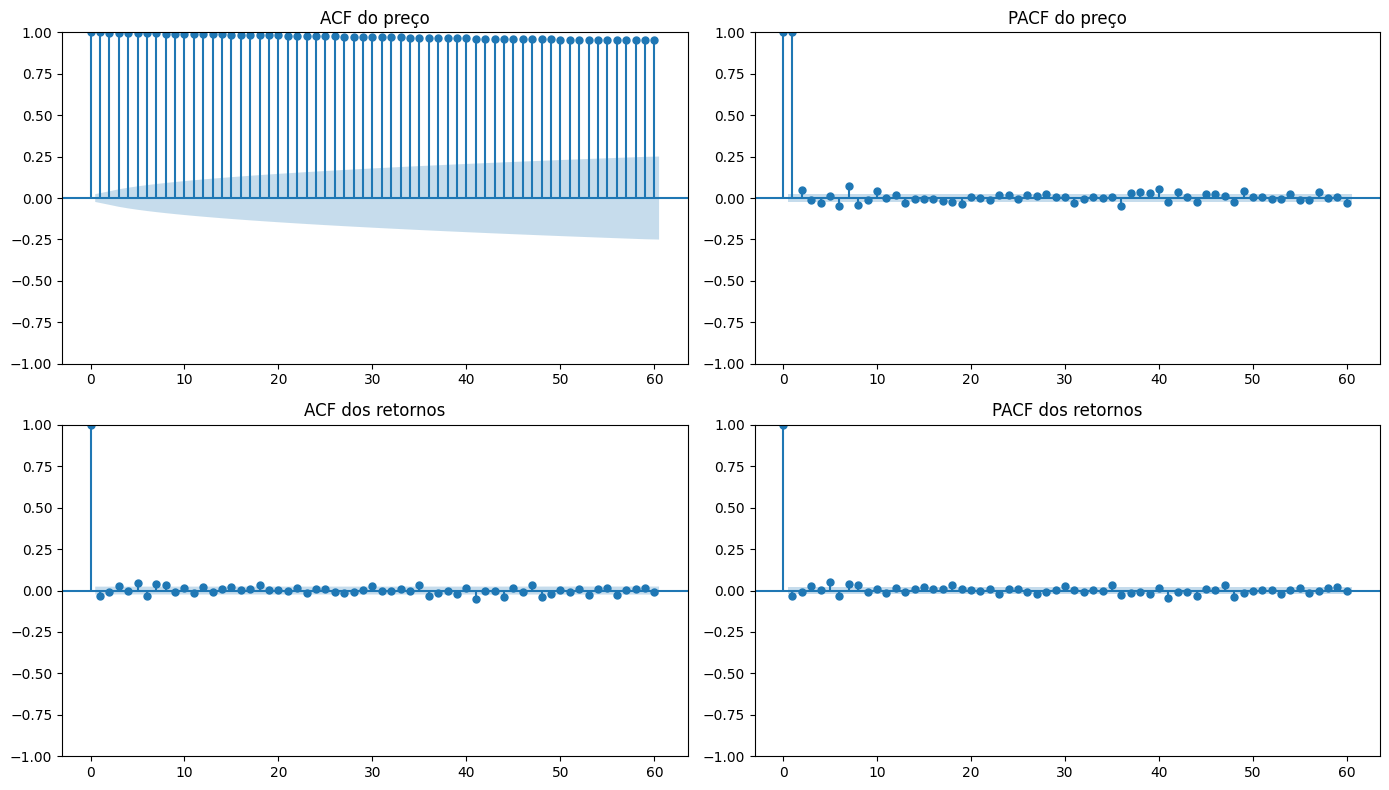

In [4]:
correlations = train[correlation_columns].corr()
display(correlations.round(3))
correlations.to_csv(OUT / "eda_correlations.csv")

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlations.columns)))
ax.set_xticklabels(correlations.columns, rotation=90)
ax.set_yticks(range(len(correlations.index)))
ax.set_yticklabels(correlations.index)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlação no trecho de treino")
plt.tight_layout()
plt.savefig(OUT / "04_correlacoes_treino.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(train["GOLD_PRICE"], lags=60, ax=axes[0, 0])
axes[0, 0].set_title("ACF do preço")
plot_pacf(train["GOLD_PRICE"], lags=60, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF do preço")
plot_acf(train["RETURN"].dropna(), lags=60, ax=axes[1, 0])
axes[1, 0].set_title("ACF dos retornos")
plot_pacf(train["RETURN"].dropna(), lags=60, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF dos retornos")
plt.tight_layout()
plt.savefig(OUT / "05_acf_pacf_treino.png", dpi=150, bbox_inches="tight")
plt.show()

adf_rows = []


In [5]:
for series_name, series in {"preço": train["GOLD_PRICE"], "retorno": train["RETURN"].dropna()}.items():
    statistic, p_value, used_lags, n_obs, critical_values, _ = adfuller(series, autolag="AIC")
    adf_rows.append(
        {
            "serie": series_name,
            "estatistica_adf": statistic,
            "p_valor": p_value,
            "lags_usados": used_lags,
            "observacoes": n_obs,
            "valor_critico_5pct": critical_values["5%"],
        }
    )

adf_table = pd.DataFrame(adf_rows)
display(adf_table.round(4))
adf_table.to_csv(OUT / "eda_adf.csv", index=False)

print("EDA concluída somente com o treino. Revise as evidências antes das decisões.")

,serie,estatistica_adf,p_valor,lags_usados,observacoes,valor_critico_5pct
0,preço,-2.0765,0.2541,35,6868,-2.862
1,retorno,-27.0900,0.0000,7,6895,-2.862


EDA concluída somente com o treino. Revise as evidências antes das decisões.


## 3. Síntese completa e gráficos finais

In [6]:
# FINAL_GOLD_EDA_ARTIFACTS
# Consolidação descritiva da série completa, sem alterar a base modelável.

GRAPH_DIR = OUT / "graficos"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
raw_gold = pd.read_csv(raw_path, sep=None, engine="python")
raw_gold["DATE"] = pd.to_datetime(raw_gold["DATE"], errors="coerce")
raw_gold["GOLD_PRICE"] = pd.to_numeric(raw_gold["VALUE"], errors="coerce")
raw_gold = raw_gold.sort_values("DATE").reset_index(drop=True)

model_data = load_data().sort_values("DATE").reset_index(drop=True)
valid_gold = raw_gold.dropna(subset=["GOLD_PRICE"]).copy()
raw_returns = valid_gold["GOLD_PRICE"].pct_change()

median_gap = valid_gold["DATE"].diff().dt.days.median()
maximum_gap = model_data["DATE"].diff().dt.days.max()
gaps_over_three = int((model_data["DATE"].diff().dt.days > 3).sum())

quality_audit = pd.read_csv(OUT / "data_quality_audit.csv")
quality_lookup = dict(zip(quality_audit["verificação"], quality_audit["valor"]))



In [7]:
summary_rows = [
    {
        "item": "periodo_serie_bruta",
        "valor": f"{raw_gold['DATE'].min().date()} a {raw_gold['DATE'].max().date()}",
        "detalhe": "período do arquivo de referência, incluindo datas com preço ausente",
    },
    {
        "item": "registros_brutos",
        "valor": int(len(raw_gold)),
        "detalhe": "todas as linhas do arquivo de ouro",
    },
    {
        "item": "registros_com_preco_valido",
        "valor": int(raw_gold["GOLD_PRICE"].notna().sum()),
        "detalhe": "linhas com GOLD_PRICE numérico",
    },
    {
        "item": "registros_modelaveis",
        "valor": int(len(model_data)),
        "detalhe": "linhas após exigir alvo, lags, janelas e externas causais disponíveis",
    },
    {
        "item": "frequencia_observada",
        "valor": "dias de mercado, calendário irregular",
        "detalhe": f"mediana do intervalo entre preços válidos = {median_gap:.0f} dia(s)",
    },
    {
        "item": "unidade",
        "valor": "USD por onça fina de ouro",
        "detalhe": "unidade oficial documentada para a série",
    },
    {
        "item": "fonte",
        "valor": "CSV de referência gold.daily.prices.csv",
        "detalhe": "fixing da tarde em Londres; código BBEX3.D.XAU.USD.EA.AC.C05",
    },
    {
        "item": "significado",
        "valor": "preço diário do ouro no fixing da tarde em Londres",
        "detalhe": "série de preço, não retorno",
    },
    {
        "item": "duplicidades_data_bruta",
        "valor": int(raw_gold["DATE"].duplicated().sum()),
        "detalhe": "datas repetidas no arquivo bruto",
    },
    {
        "item": "duplicidades_data_modelavel",
        "valor": int(model_data["DATE"].duplicated().sum()),
        "detalhe": "datas repetidas na base usada pelos modelos",
    },
    {
        "item": "precos_ausentes",
        "valor": int(raw_gold["GOLD_PRICE"].isna().sum()),
        "detalhe": "não imputados; linhas excluídas da base modelável",
    },
    {
        "item": "maior_intervalo_modelavel_dias",
        "valor": int(maximum_gap),
        "detalhe": "irregularidade de calendário observada após a filtragem causal",
    },
    {
        "item": "intervalos_modelaveis_maiores_que_3_dias",
        "valor": gaps_over_three,
        "detalhe": "feriados, fins de semana prolongados e lacunas da série",
    },
    {
        "item": "extremos_nivel_preco_iqr",
        "valor": int(quality_lookup["extremos pelo IQR no nível do preço"]),
        "detalhe": "sinaliza regimes de nível; não implica erro de dado",
    },
    {
        "item": "retornos_extremos_mad",
        "valor": int(quality_lookup["retornos extremos pelo MAD"]),
        "detalhe": "movimentos incomuns preservados por não haver evidência de erro",
    },
]



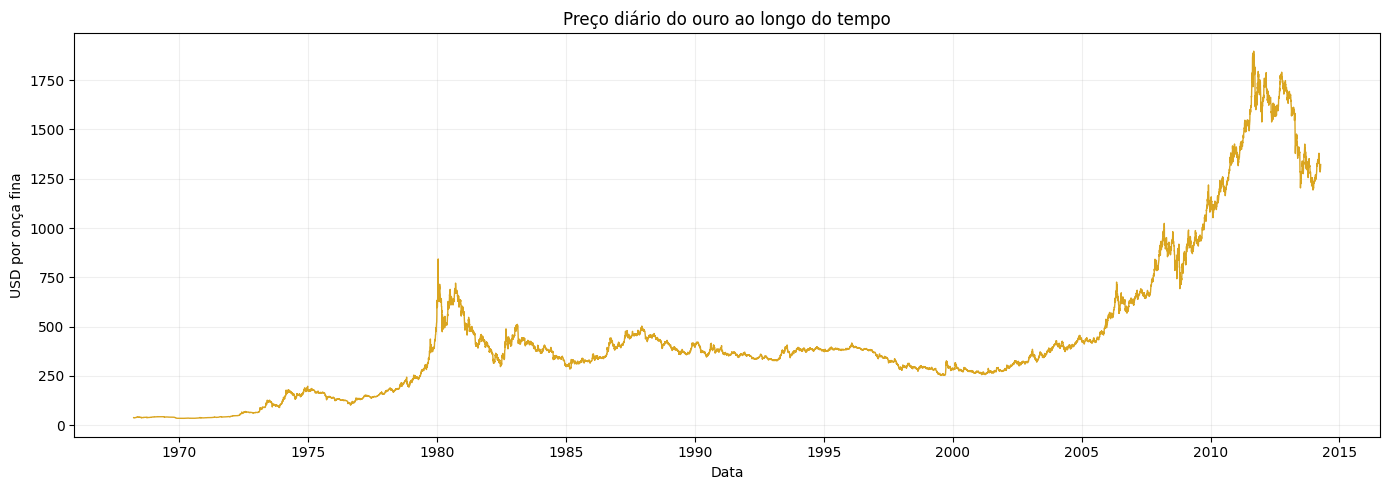

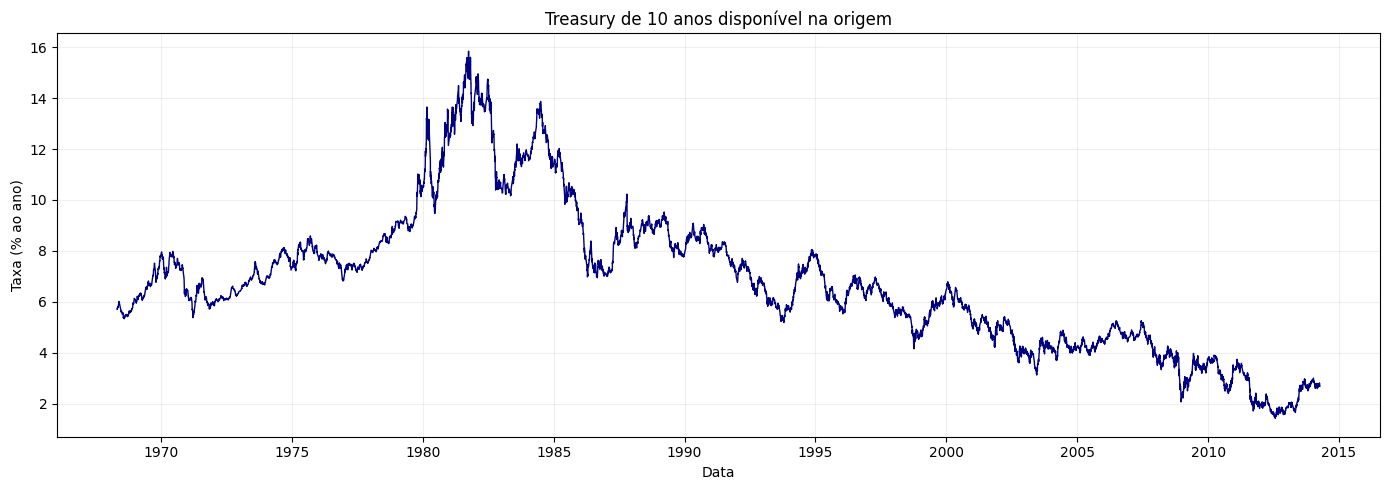

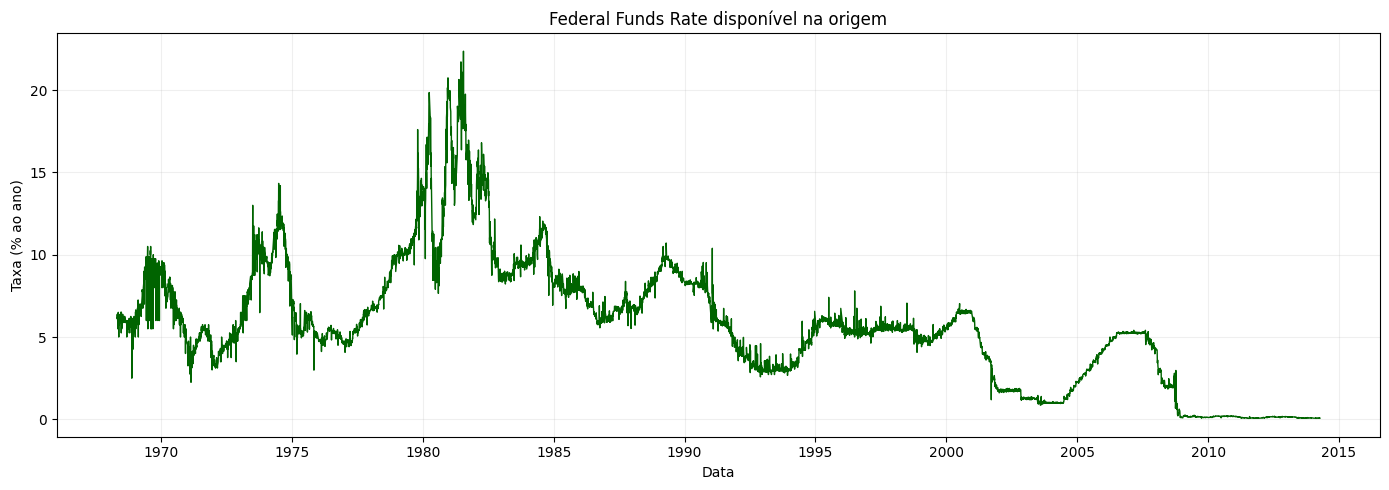

In [8]:
exploratory_summary = pd.DataFrame(summary_rows)
exploratory_summary.to_csv(OUT / "exploratory_summary.csv", index=False)

missing_audit = raw_gold.loc[raw_gold["GOLD_PRICE"].isna(), ["DATE", "GOLD_PRICE"]].copy()
missing_audit["status"] = "ausente no arquivo bruto"
missing_audit["tratamento"] = (
    "sem interpolação e sem preenchimento do ouro; linha excluída da base modelável"
)
missing_audit.to_csv(OUT / "missing_values_audit.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(valid_gold["DATE"], valid_gold["GOLD_PRICE"], color="goldenrod", linewidth=1)
ax.set_title("Preço diário do ouro ao longo do tempo")
ax.set_xlabel("Data")
ax.set_ylabel("USD por onça fina")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "gold_price_full.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(model_data["DATE"], model_data["TREASURY_10Y"], color="navy", linewidth=1)
ax.set_title("Treasury de 10 anos disponível na origem")
ax.set_xlabel("Data")
ax.set_ylabel("Taxa (% ao ano)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "treasury_10y_full.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(model_data["DATE"], model_data["FED_FUNDS_RATE"], color="darkgreen", linewidth=1)
ax.set_title("Federal Funds Rate disponível na origem")
ax.set_xlabel("Data")
ax.set_ylabel("Taxa (% ao ano)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "fed_funds_rate_full.png", dpi=160, bbox_inches="tight")
plt.show()



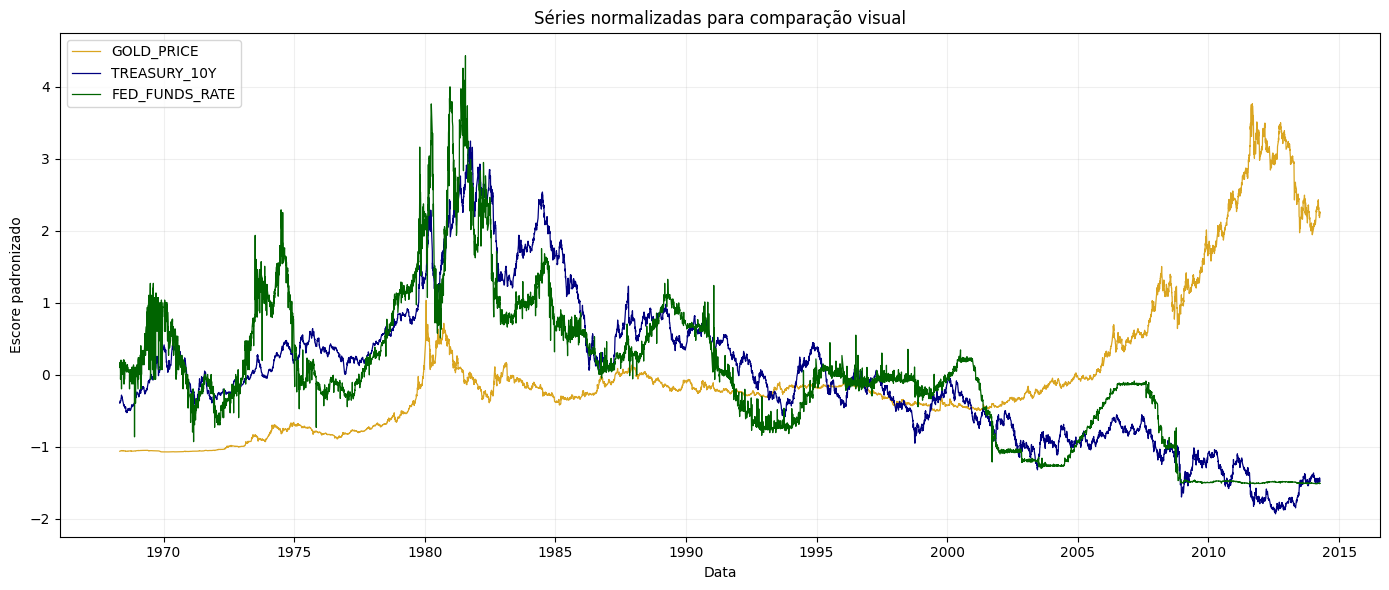

,item,valor,detalhe
0,periodo_serie_bruta,1968-04-01 a 2014-04-10,"período do arquivo de referência, incluindo da..."
1,registros_brutos,12009,todas as linhas do arquivo de ouro
2,registros_com_preco_valido,11641,linhas com GOLD_PRICE numérico
3,registros_modelaveis,9864,"linhas após exigir alvo, lags, janelas e exter..."
4,frequencia_observada,"dias de mercado, calendário irregular",mediana do intervalo entre preços válidos = 1 ...
5,unidade,USD por onça fina de ouro,unidade oficial documentada para a série
6,fonte,CSV de referência gold.daily.prices.csv,fixing da tarde em Londres; código BBEX3.D.XAU...
7,significado,preço diário do ouro no fixing da tarde em Lon...,"série de preço, não retorno"
8,duplicidades_data_bruta,0,datas repetidas no arquivo bruto
9,duplicidades_data_modelavel,0,datas repetidas na base usada pelos modelos


,DATE,GOLD_PRICE,status,tratamento
9,1968-04-12,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
10,1968-04-15,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
45,1968-06-03,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
110,1968-09-02,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
192,1968-12-25,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
193,1968-12-26,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
197,1969-01-01,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
264,1969-04-04,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
265,1969-04-07,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...
300,1969-05-26,NaN,ausente no arquivo bruto,sem interpolação e sem preenchimento do ouro; ...


Artefatos finais de EDA gerados. Ausentes documentados: 368.


In [9]:
normalized = model_data.set_index("DATE")[[
    "GOLD_PRICE", "TREASURY_10Y", "FED_FUNDS_RATE"
]].copy()
normalized = (normalized - normalized.mean()) / normalized.std(ddof=1)

fig, ax = plt.subplots(figsize=(14, 6))
for column, color in {
    "GOLD_PRICE": "goldenrod",
    "TREASURY_10Y": "navy",
    "FED_FUNDS_RATE": "darkgreen",
}.items():
    ax.plot(normalized.index, normalized[column], label=column, color=color, linewidth=0.9)
ax.set_title("Séries normalizadas para comparação visual")
ax.set_xlabel("Data")
ax.set_ylabel("Escore padronizado")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "series_normalized_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(exploratory_summary)
display(missing_audit.head(10))
print(f"Artefatos finais de EDA gerados. Ausentes documentados: {len(missing_audit)}.")

## Interpretação

O preço apresenta forte persistência e mudanças de nível ao longo do tempo. A série é de dias de mercado, com calendário irregular, e as externas são exibidas apenas com a disponibilidade causal definida no protocolo.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/exploratory_summary.csv`
- `outputs/missing_values_audit.csv`
- `outputs/eda_adf.csv`
- `outputs/graficos/`